# Ensemblr: Structural Ensemble Analysis Pipeline

This notebook walks through the complete ensemblr workflow using the class-based API: from raw AlphaFold2 outputs to umbrella sampling window setup. All user-configurable parameters are consolidated in **Section 1 (Setup)**.

| Section | Description |
|---------|-------------|
| 1. Setup | Imports and all configurable parameters |
| 2. Load Ensemble | Gather AF2 outputs, filter by pLDDT and atom count |
| 3. Selection & PCA | Generate RMSD/PCA selection; run dimensionality reduction |
| 4. Clustering | Identify representative structures via HDBSCAN |
| 5. Structural Properties | RMSD, SASA, and user-defined distances |
| 6. Visualisation | Ensemble density and property plots |
| 7. Property Matrices | Pairwise RMSD and CV matrices |
| 8. Path Optimisation | Bin structures and run MC simulated annealing |
| 9. Path Assessment | Evaluate quality of the optimised path |
| 10. Umbrella Sampling Setup | Embed structures and write PLUMED input files |
| 11. Debugging | Verify PLUMED CV values against MDA projections |

## 1. Setup

All imports and user-configurable parameters live here. Edit the **SETTINGS** block before running the notebook — everything below the settings block runs automatically.

In [24]:
# ── Suppress warnings / logging BEFORE any imports ───────────────────────────
import warnings
warnings.filterwarnings('ignore')

import os
os.environ["JAX_PLATFORMS"] = "cpu"       # prevent JAX GPU-search spam
os.environ["OMP_NUM_THREADS"] = "1"       # placeholder; overwritten below

# ── Imports ───────────────────────────────────────────────────────────────────
import glob
import pickle
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import jax

from IPython.display import display
from ensemblr import Ensemble, MCPathFinder, UmbrellaSamplingPrep

# Silence noisy loggers that bypass Python's warnings system
for _log in ('absl', 'jax', 'jax._src.xla_bridge', 'MDAnalysis', 'numexpr'):
    logging.getLogger(_log).setLevel(logging.ERROR)

# ── SETTINGS ──────────────────────────────────────────────────────────────────

# Base directories
base_directory     = "/biggin/b212/bioc1781/Projects/CTNS/human/monomer/red-msa/with-dropout/raw_colabfold_outputs/"

# Run name — all outputs for this run go to out_dir; change to keep runs separate
run_name = "run_01"
out_dir  = base_directory + run_name + "/"
structure_directory = base_directory + run_name + "/ensemble/"  # destination for AF2 PDBs

# MSA depths used in the AF2 run (determines output directory naming)
msa_depths = ['8-16', '16-32', '32-64', '64-128', '128-256', '256-512', '512-1024']

# pLDDT threshold — structures below this value are discarded
thresh_pLDDT = 85

# Residue selections for RMSD and PCA calculations
conserved_residues = ""
ignored_residues   = ""
always_include     = ""

# Optional: MDAnalysis selection tokens for distance CVs
IF_ref1 = ""
IF_ref2 = ""
OF_ref1 = ""
OF_ref2 = ""

# Optional: named inter-atomic distances to compute and add to the ensemble dataframe
distances_to_evaluate = {'OF_gate': (OF_ref1, OF_ref2),
                         'IF_gate': (IF_ref1, IF_ref2)}

# Optional: external reference structures to compute RMSD against for every ensemble structure.
# Format: {label: absolute_path} — adds a 'rmsd_to_{label}' column to ens.df for each entry.
# Use these to identify which ensemble structures are closest to known end states.
# Set user_ref_resid_offset if the reference structures have different residue numbering than
# the ensemble (e.g. crystal structures offset by a signal peptide).
user_specified_structures = {'IF': '/biggin/b212/bioc1781/Projects/CTNS/human/monomer/red-msa/with-dropout/8DKE_IF.pdb', 'OF': '/biggin/b212/bioc1781/Projects/CTNS/human/monomer/red-msa/with-dropout/8DKI_OF.pdb'}   # e.g. {'IF': '/path/to/IF.pdb', 'OF': '/path/to/OF.pdb'}
user_ref_resid_offset     = 0    # residue ID offset applied to user-specified reference structures

# Toggle optional per-structure calculations
load_relaxed        = True   # set False to load _unrelaxed_ PDBs instead of _relaxed_
calculate_rmsd      = True
calculate_sasa      = False
calculate_distances = False

# CPU cores for parallelised steps
num_processes = 6

# Number of principal components to retain
n_pcs = 3

# Collective variable for MC path optimisation and umbrella sampling
collective_variable   = 'PC1'
collective_variable_2 = 'PC2'

# Step-cost matrix for MC path optimisation: 'rmsd' or 'rama'
step_matrix_type = 'rama'

# MC path optimisation settings
mc_n_bins          = 32    # number of umbrella sampling windows
mc_n_runs          = 100   # number of independent MC runs
mc_n_paths_to_save = 5     # number of top-ranked paths to write as PDB files
reproducible_seeds = False
fixed_endstates    = False  # freeze end-state structures during MC
mc_wf_step         = 1.0   # weight for step-cost (RMSD/Rama) term relative to CV term (wf_cv=1)
mc_wf_cv           = 1.0   # weight for primary CV term
mc_wf_odf          = None  # None → auto (PC2_eig/PC1_eig when CV2 is a PC); set float to override

# Template PDB for umbrella sampling (protein + membrane + solvent)
template_pdb_for_umbrella_sampling = '/biggin/b212/bioc1781/Projects/CTNS/human/monomer/red-msa/with-dropout/template_D305p_smallbilayer.pdb'
resid_offset = 115  # offset applied to residue IDs when writing output structures

# Default axes for ensemble plots
plot_variable_1 = 'PC1'
plot_variable_2 = 'PC2'
plot_variable_3 = 'IF_gate'

# ── END SETTINGS ──────────────────────────────────────────────────────────────

os.makedirs(out_dir, exist_ok=True)
os.environ["OMP_NUM_THREADS"] = str(num_processes)

pd.set_option('display.max_colwidth', None)

cmap   = plt.colormaps['tab20c']
colors = cmap(np.linspace(0, 1, 10))
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors)

# ── Shared formatting helper ──────────────────────────────────────────────────
def _banner(title, width=64):
    bar = '─' * width
    print(f'\n{bar}\n  {title}\n{bar}')

# ── Summary ───────────────────────────────────────────────────────────────────
_banner("1. Setup")
print(f"  Output dir       : {out_dir}")
print(f"  Structures dir   : {structure_directory}")
print(f"  pLDDT threshold  : {thresh_pLDDT}")
print(f"  CPU cores        : {num_processes}")
print(f"  Step matrix      : {step_matrix_type}")
print(f"  JAX devices      : {jax.devices()}")


────────────────────────────────────────────────────────────────
  1. Setup
────────────────────────────────────────────────────────────────
  Output dir       : /biggin/b212/bioc1781/Projects/CTNS/human/monomer/red-msa/with-dropout/raw_colabfold_outputs/run_01/
  Structures dir   : /biggin/b212/bioc1781/Projects/CTNS/human/monomer/red-msa/with-dropout/raw_colabfold_outputs/run_01/ensemble/
  pLDDT threshold  : 85
  CPU cores        : 6
  Step matrix      : rama
  JAX devices      : [CpuDevice(id=0)]


## 2. Load Ensemble

Gathers relaxed PDB files from each MSA-depth output directory, parses pLDDT scores from the AF2 log files, filters out structures below `thresh_pLDDT`, and drops any structures with fewer than the maximum atom count to ensure topological consistency.

In [25]:
_banner("2. Load Ensemble")

ens = Ensemble(structure_directory, thresh_pLDDT=thresh_pLDDT)
ens.load_from_af2(base_directory, msa_depths, relaxed=load_relaxed)

print(f"\n  {len(ens.df)} structures loaded")
print(f"  pLDDT range : {ens.df['pLDDT'].min():.1f} – {ens.df['pLDDT'].max():.1f}")
#display(ens.df)


────────────────────────────────────────────────────────────────
  2. Load Ensemble
────────────────────────────────────────────────────────────────
Loaded 11928 structures (pLDDT > 85, 3957 atoms)

  11928 structures loaded
  pLDDT range : 85.1 – 94.3


## 3. Selection & PCA

Generates an MDAnalysis selection token using DSSP secondary structure information from the highest-pLDDT structure, then runs PCA on the aligned ensemble. PC projections are stored in `ens.df`. Visualisation PDBs for each PC are written to `output_dir`.

In [26]:
import types

_banner("3. Selection & PCA")

ens.build_selection(
    conserved_residues=conserved_residues,
    excluded_residues=ignored_residues,
    always_include=always_include,
    output_file=out_dir + 'rmsd_selection.pdb',
)
print(f"  Selection : {ens.rmsd_selection}")

_pca_checkpoint = out_dir + 'pca_checkpoint.npz'
pc_cols = [f'PC{i+1}' for i in range(n_pcs)]
_pca_valid = False

if os.path.exists(_pca_checkpoint):
    _npz = np.load(_pca_checkpoint)
    if 'PC1' in _npz and _npz['PC1'].shape[0] == len(ens.df):
        for c in pc_cols:
            ens.df[c] = _npz[c]
        ens.pca = types.SimpleNamespace(
            p_components=_npz['p_components'],
            mean=_npz['mean'],
            cumulated_variance=_npz['cumulated_variance'],
            variance=(_npz['variance'] if 'variance' in _npz
                     else np.diff(np.concatenate([[0], _npz['cumulated_variance']]))),
        )
        ens._ensemble_pdb = out_dir + 'ensemble.pdb'
        cumvar = {i+1: round(float(v)*100, 1) for i, v in enumerate(_npz['cumulated_variance'][:n_pcs])}
        print(f"  Loaded from checkpoint\n  Cumulative variance (%): {cumvar}")
        _pca_valid = True
    else:
        print("  Checkpoint size mismatch — will recompute")

if not _pca_valid:
    ens.run_pca(n_components=n_pcs, output_dir=out_dir)
    np.savez(
        _pca_checkpoint,
        p_components=ens.pca.p_components,
        mean=np.asarray(ens.pca.mean).flatten(),
        cumulated_variance=np.asarray(list(ens.pca.cumulated_variance)),
        variance=np.asarray(list(ens.pca.variance[:n_pcs])),
        **{c: ens.df[c].values for c in pc_cols},
    )
    print(f"  Saved checkpoint: {_pca_checkpoint}")

print(f"\n  PC projections (first 5 rows):")
#display(ens.df[pc_cols].head())

# Auto-set mc_wf_odf from eigenvalue ratio when CV2 is a PC
if mc_wf_odf is None:
    if (collective_variable_2 is not None
            and collective_variable_2.startswith('PC')
            and collective_variable.startswith('PC')):
        _cv1_idx = int(collective_variable[2:]) - 1
        _cv2_idx = int(collective_variable_2[2:]) - 1
        mc_wf_odf = float(ens.pca.variance[_cv2_idx] / ens.pca.variance[_cv1_idx])
        print(f'  Auto wf_odf = {mc_wf_odf:.3f}  '
              f'(variance ratio {collective_variable_2}/{collective_variable})')
    else:
        mc_wf_odf = 0.0



────────────────────────────────────────────────────────────────
  3. Selection & PCA
────────────────────────────────────────────────────────────────
  Selection : ((((resid 6-37) or (resid 45-67) or (resid 69-78) or (resid 88-110) or (resid 120-141) or (resid 147-176) or (resid 184-207) or (resid 211-215) or (resid 218-241)) and name CA) or (((resid 38-38) or (resid 41-43) or (resid 80-81) or (resid 85-85) or (resid 111-111) or (resid 114-115) or (resid 142-145) or (resid 177-177) or (resid 180-182) or (resid 208-209) or (resid 216-217)) and name CA) or (((resid 39-39) or (resid 112-112)) and name CA))
  Loaded from checkpoint
  Cumulative variance (%): {1: 75.9, 2: 88.6, 3: 90.9}

  PC projections (first 5 rows):
  Auto wf_odf = 0.167  (variance ratio PC2/PC1)


## 4. Clustering

Clusters the ensemble in PC space using HDBSCAN (minimum samples = 10% of ensemble size). Cluster medoids are used as representative structures and become the default RMSD reference set. Override by setting `use_reference_structures = True` in the settings.


────────────────────────────────────────────────────────────────
  4. Clustering
────────────────────────────────────────────────────────────────
2 clusters. Medoids: ['msa-512-1024_rank_258.pdb', 'msa-32-64_rank_915.pdb']

  Clusters : 2  |  Noise points : 994
  Medoids  : ['msa-512-1024_rank_258.pdb', 'msa-32-64_rank_915.pdb']

  Top-pLDDT structure per cluster:


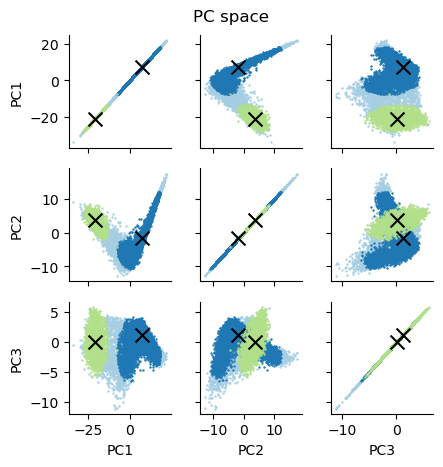

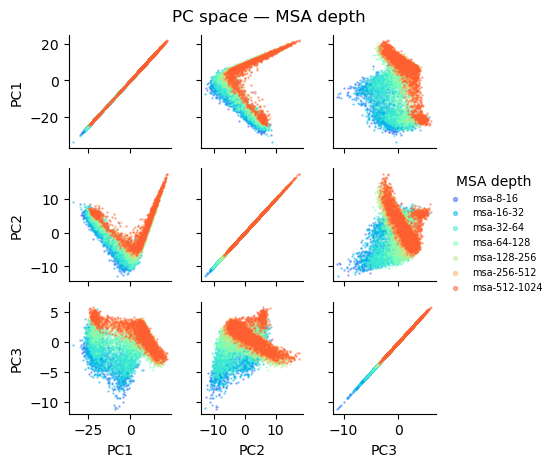

In [27]:
_banner("4. Clustering")

ref_structures = ens.cluster()

num_clusters = ens.df['cluster'].nunique() - (1 if -1 in ens.df['cluster'].values else 0)
n_noise      = (ens.df['cluster'] == -1).sum()

print(f"\n  Clusters : {num_clusters}  |  Noise points : {n_noise}")
print(f"  Medoids  : {ref_structures}")

cluster_best_pLDDT = [
    ens.df[ens.df['cluster'] == i].sort_values('pLDDT', ascending=False).index[0]
    for i in range(num_clusters)
]
print(f"\n  Top-pLDDT structure per cluster:")
#display(ens.df.loc[ens.df.index.isin(cluster_best_pLDDT)].sort_values('pLDDT', ascending=False))

if 'cluster' in ens.df.columns:
    g = sns.PairGrid(ens.df[pc_cols + ['cluster']], vars=pc_cols, hue='cluster',
                     height=1.5, palette='Paired')
    g.map(plt.scatter, marker='.', s=2)
    for rep in ref_structures:
        for i in range(len(pc_cols)):
            for j in range(len(pc_cols)):
                g.axes[i][j].scatter(
                    ens.df.loc[rep, pc_cols[j]], ens.df.loc[rep, pc_cols[i]],
                    c='black', marker='x', s=100, zorder=10,
                )
else:
    g = sns.PairGrid(ens.df[pc_cols], height=1.5)
    g.map(plt.scatter, marker='.', s=2)
plt.suptitle('PC space', y=1.02)
plt.show()

# ── PC space coloured by MSA depth ───────────────────────────────────────────
_msa_labels = ens.df.index.str.extract(r'^(msa-[\d\-]+)', expand=False).fillna('other')
_msa_order  = sorted(_msa_labels.unique(),
                     key=lambda x: int(x.split('-')[1]) if x != 'other' else 0)

_plot_df = ens.df[pc_cols].copy()
_plot_df['msa'] = pd.Categorical(_msa_labels, categories=_msa_order, ordered=True)

g = sns.PairGrid(_plot_df, vars=pc_cols, hue='msa', hue_order=_msa_order,
                 height=1.5, palette='rainbow')
g.map(plt.scatter, marker='.', s=2, alpha=0.5)
g.add_legend(markerscale=4, fontsize=7, title='MSA depth')
plt.suptitle('PC space — MSA depth', y=1.02)
plt.show()

## 5. Structural Properties

Computes per-structure properties in parallel and adds them as columns to `ens.df`: RMSD to each reference structure, solvent-accessible surface area, and user-defined inter-atomic distances.

In [28]:
_banner("5. Structural Properties")

_df_checkpoint = out_dir + 'ensemble_df.parquet'

_want_rmsd  = [f'rmsd_to_{r}' for r in ref_structures] if calculate_rmsd else []
_want_dists = list(distances_to_evaluate.keys())        if calculate_distances else []
_want_sasa  = ['sasa']                                  if calculate_sasa else []
_want_refs  = [f'rmsd_to_{k}' for k in user_specified_structures] if user_specified_structures else []
_want_all   = _want_rmsd + _want_dists + _want_sasa + _want_refs

# Restore any already-computed columns that are still valid for this ensemble
if os.path.exists(_df_checkpoint):
    _saved = pd.read_parquet(_df_checkpoint)
    if _saved.index.equals(ens.df.index):
        for c in [c for c in _want_all if c in _saved.columns and c not in ens.df.columns]:
            ens.df[c] = _saved[c]
    else:
        print(f"  Note: checkpoint has {len(_saved)} structures vs {len(ens.df)} — will recompute")

# Compute anything still missing (covers first run, changed threshold, changed ref structures)
_missing_rmsd  = [r for r in ref_structures if f'rmsd_to_{r}' not in ens.df.columns]
_missing_dists = {k: v for k, v in distances_to_evaluate.items()
                  if k not in ens.df.columns and all(v)} if calculate_distances else {}
_missing_sasa  = calculate_sasa and 'sasa' not in ens.df.columns
_missing_refs  = {k: v for k, v in user_specified_structures.items()
                  if f'rmsd_to_{k}' not in ens.df.columns} if user_specified_structures else {}

if _missing_rmsd or _missing_dists or _missing_sasa:
    ens.compute_metrics(
        ref_structures=_missing_rmsd,
        distances=_missing_dists or None,
        compute_sasa=_missing_sasa,
        num_processes=num_processes,
    )
    ens.df.to_parquet(_df_checkpoint)
    print(f"  Saved → {_df_checkpoint}")

if _missing_refs:
    ens.compute_reference_rmsds(_missing_refs, ref_resid_offset=user_ref_resid_offset,
                                num_processes=num_processes)
    ens.df.to_parquet(_df_checkpoint)
    print(f"  Saved → {_df_checkpoint}")

if not (_missing_rmsd or _missing_dists or _missing_sasa or _missing_refs):
    print(f"  Loaded from checkpoint")

print(f"\n  Ensemble dataframe  ({len(ens.df)} rows × {len(ens.df.columns)} cols):")
#display(ens.df)

# ── Closest structures to user-specified references ──────────────────────────
if user_specified_structures:
    print("\n  Closest ensemble structures to user-specified references:")
    for label in user_specified_structures:
        col = f'rmsd_to_{label}'
        closest = ens.df[col].idxmin()
        print(f"    {label}: {closest}  (RMSD = {ens.df.loc[closest, col]:.2f} Å)")
    print("\n  To use these as fixed end states in MC optimisation, set:")
    print("    fixed_endstates = True")
    print("  and in Section 8 (bin_structures), override the initial path endpoints manually.")


────────────────────────────────────────────────────────────────
  5. Structural Properties
────────────────────────────────────────────────────────────────


RMSD → OF: 100%|██████████| 11928/11928 [00:00<00:00, 5439780.16it/s]

  Saved → /biggin/b212/bioc1781/Projects/CTNS/human/monomer/red-msa/with-dropout/raw_colabfold_outputs/run_01/ensemble_df.parquet

  Ensemble dataframe  (11928 rows × 9 cols):

  Closest ensemble structures to user-specified references:
    IF: msa-16-32_rank_886.pdb  (RMSD = 0.93 Å)
    OF: msa-512-1024_rank_1611.pdb  (RMSD = 1.01 Å)

  To use these as fixed end states in MC optimisation, set:
    fixed_endstates = True
  and in Section 8 (bin_structures), override the initial path endpoints manually.


## 6. Visualisation

Plots ensemble density in PC space (hexbin), overlaid distance distributions, RMSD histograms, and SASA/pLDDT distributions. Reference structures are annotated with crosses.


────────────────────────────────────────────────────────────────
  6. Visualisation
────────────────────────────────────────────────────────────────


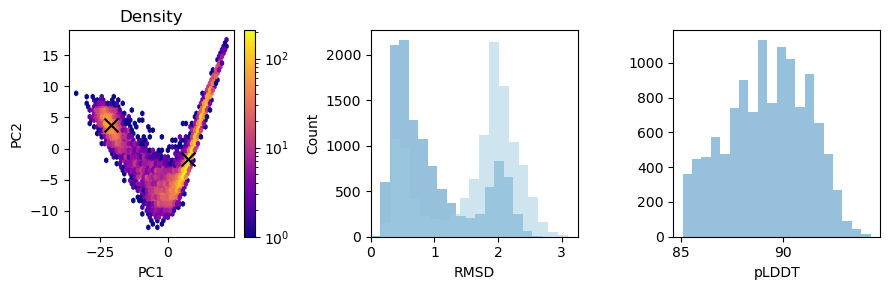

In [29]:
_banner("6. Visualisation")

valid_distances = []
if calculate_distances and distances_to_evaluate:
    valid_distances = [d for d in distances_to_evaluate if not ens.df[d].isna().all()]

n_hex_panels = 1 + len(valid_distances)
n_hist       = (1 if calculate_rmsd else 0) + (1 if calculate_sasa else 0) + 1
ncols        = n_hex_panels + n_hist

fig, axes = plt.subplots(1, ncols, figsize=(3 * ncols, 3))
axes = np.atleast_1d(axes)

# ── hexbin panels ──────────────────────────────────────────────────────────
hb = axes[0].hexbin(ens.df[plot_variable_1], ens.df[plot_variable_2],
                    cmap='plasma', gridsize=50, mincnt=1, bins='log')
axes[0].set_xlabel(plot_variable_1); axes[0].set_ylabel(plot_variable_2)
fig.colorbar(hb, ax=axes[0]); axes[0].set_title('Density')
for ref in ref_structures:
    axes[0].scatter(ens.df.loc[ref, plot_variable_1], ens.df.loc[ref, plot_variable_2],
                    c='black', marker='x', s=100)
    #axes[0].annotate(ref, (ens.df.loc[ref, plot_variable_1], ens.df.loc[ref, plot_variable_2]))

for i, distance_name in enumerate(valid_distances):
    hb = axes[1 + i].hexbin(ens.df[plot_variable_1], ens.df[plot_variable_2],
                             C=ens.df[distance_name], cmap='coolwarm', gridsize=50, mincnt=1)
    axes[1 + i].set_xlabel(plot_variable_1); axes[1 + i].set_ylabel(plot_variable_2)
    fig.colorbar(hb, ax=axes[1 + i], label=distance_name)
    axes[1 + i].set_title(distance_name)

# ── histogram panels ────────────────────────────────────────────────────────
ax_idx = n_hex_panels

if calculate_rmsd:
    for ref in ref_structures:
        axes[ax_idx].hist(ens.df[f'rmsd_to_{ref}'], bins=20, alpha=0.5, label=ref)
    #axes[ax_idx].legend(loc='upper right')
    axes[ax_idx].set_xlabel('RMSD'); axes[ax_idx].set_ylabel('Count')
    axes[ax_idx].set_xlim(0)
    ax_idx += 1

if calculate_sasa:
    axes[ax_idx].hist(ens.df['sasa'], bins=20, alpha=0.5, color='C3')
    axes[ax_idx].set_xlabel('SASA'); axes[ax_idx].set_ylabel('Count')
    ax_idx += 1

axes[ax_idx].hist(ens.df['pLDDT'], bins=20, alpha=0.5)
axes[ax_idx].set_xlabel('pLDDT')

plt.tight_layout()
plt.show()


────────────────────────────────────────────────────────────────
  6b. Closest Structures to User-Specified References
────────────────────────────────────────────────────────────────
  IF: msa-16-32_rank_886.pdb  (RMSD = 0.93 Å)
  OF: msa-512-1024_rank_1611.pdb  (RMSD = 1.01 Å)


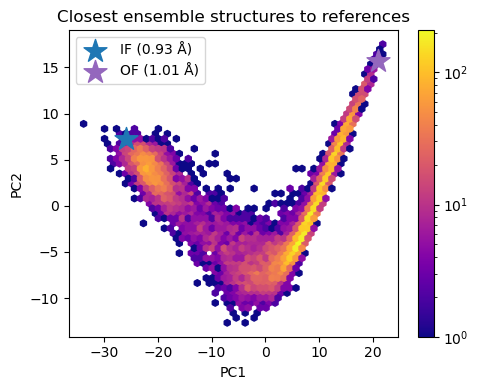

In [30]:
# ── Closest structures to user-specified references (PCA overlay) ─────────────
if user_specified_structures:
    _banner("6b. Closest Structures to User-Specified References")

    closest_structures = {}
    for label, ref_path in user_specified_structures.items():
        structure, rmsd = ens.get_closest_structure(
            ref_path, ref_resid_offset=user_ref_resid_offset, num_processes=num_processes
        )
        closest_structures[label] = (structure, rmsd)
        print(f"  {label}: {structure}  (RMSD = {rmsd:.2f} Å)")

    fig, ax = plt.subplots(figsize=(5, 4))
    hb = ax.hexbin(ens.df[plot_variable_1], ens.df[plot_variable_2],
                   cmap='plasma', gridsize=50, mincnt=1, bins='log')
    fig.colorbar(hb, ax=ax)

    colors_ref = plt.colormaps['tab10'](np.linspace(0, 0.4, len(closest_structures)))
    for (label, (structure, rmsd)), color in zip(closest_structures.items(), colors_ref):
        ax.scatter(ens.df.loc[structure, plot_variable_1],
                   ens.df.loc[structure, plot_variable_2],
                   color=color, marker='*', s=300, zorder=10, label=f'{label} ({rmsd:.2f} Å)')

    ax.set_xlabel(plot_variable_1)
    ax.set_ylabel(plot_variable_2)
    ax.set_title('Closest ensemble structures to references')
    ax.legend(loc='best')
    plt.tight_layout()
    plt.show()

## 7. Property Matrices

Builds pairwise matrices over the ensemble required as inputs to the Monte Carlo path optimisation: all-vs-all RMSD (via JAX), and CV difference matrices.


────────────────────────────────────────────────────────────────
  7. Property Matrices
────────────────────────────────────────────────────────────────
  Checkpoint size mismatch or wrong type — will recompute


Rama matrix: 100%|██████████| 187/187 [11:34<00:00,  3.71s/it]


Matrices computed — Rama: (11928, 11928), CV (PC1): (11928, 11928)
  Saved → /biggin/b212/bioc1781/Projects/CTNS/human/monomer/red-msa/with-dropout/raw_colabfold_outputs/run_01/matrices_rama.npz
  Step matrix (rama) : (11928, 11928)  min=0.00  max=0.36


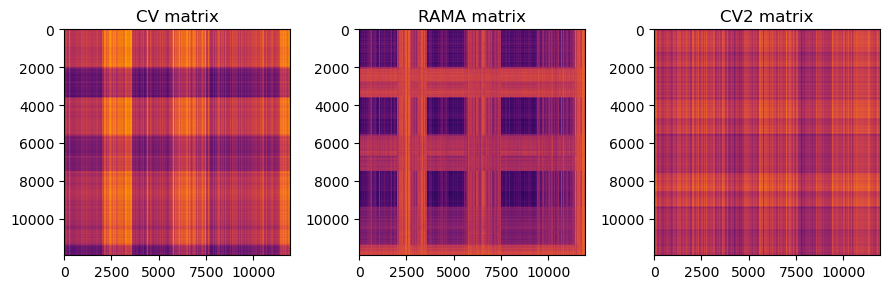

In [ ]:
_banner("7. Property Matrices")

_matrices_checkpoint = out_dir + f'matrices_{step_matrix_type}.npz'
_n = len(ens.df)
_matrices_valid = False

if os.path.exists(_matrices_checkpoint):
    _npz = np.load(_matrices_checkpoint)
    _step_key = step_matrix_type + '_matrix'
    if _step_key in _npz and _npz[_step_key].shape[0] == _n:
        setattr(ens, _step_key, _npz[_step_key])
        ens.cv_matrix  = _npz['cv_matrix']
        ens.cv2_matrix = _npz['cv2_matrix'] if 'cv2_matrix' in _npz else None
        _matrices_valid = True
        print(f"  Loaded from checkpoint")
    else:
        print(f"  Checkpoint size mismatch or wrong type — will recompute")

if not _matrices_valid:
    ens.compute_matrices(cv_column=collective_variable, cv2_column=collective_variable_2,
                         step_matrix=step_matrix_type)
    _step_key = step_matrix_type + '_matrix'
    _save = {_step_key: getattr(ens, _step_key), 'cv_matrix': ens.cv_matrix}
    if ens.cv2_matrix is not None:
        _save['cv2_matrix'] = ens.cv2_matrix
    np.savez(_matrices_checkpoint, **_save)
    print(f"  Saved → {_matrices_checkpoint}")

_step_matrix = ens.rama_matrix if step_matrix_type == 'rama' else ens.rmsd_matrix
print(f"  Step matrix ({step_matrix_type}) : {_step_matrix.shape}  "
      f"min={_step_matrix.min():.2f}  max={_step_matrix.max():.2f}")

matrices = [ens.cv_matrix, _step_matrix]
titles   = ['CV matrix', f'{step_matrix_type.upper()} matrix']
if ens.cv2_matrix is not None:
    matrices.append(ens.cv2_matrix); titles.append('CV2 matrix')

fig, axes = plt.subplots(1, len(matrices), figsize=(3 * len(matrices), 3))
axes = np.atleast_1d(axes)
for ax, matrix, title in zip(axes, matrices, titles):
    ax.imshow(matrix, cmap='inferno'); ax.set_title(title)
plt.tight_layout()
plt.show()

## 8. Path Optimisation

Bins structures along the collective variable with KMeans, then runs `mc_n_runs` independent Monte Carlo simulated annealing optimisations in parallel. The energy function penalises large Cartesian RMSD steps and uneven CV spacing between adjacent windows. Results are sorted by total path energy.


────────────────────────────────────────────────────────────────
  8. Path Optimisation — Binning
────────────────────────────────────────────────────────────────
  Bins        : 32
  Structures/bin — min: 26  max: 722  mean: 372.8


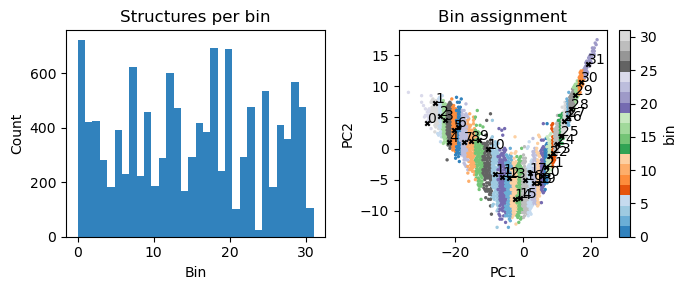

In [ ]:
_banner("8. Path Optimisation — Binning")

finder = MCPathFinder(ens, n_bins=mc_n_bins, cv=collective_variable, cv2=collective_variable_2)
finder.bin_structures()

_bin_counts = ens.df['bin'].value_counts()
print(f"  Bins        : {mc_n_bins}")
print(f"  Structures/bin — min: {_bin_counts.min()}  max: {_bin_counts.max()}  "
      f"mean: {_bin_counts.mean():.1f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3))

ax1.hist(ens.df['bin'], bins=mc_n_bins)
ax1.set_xlabel('Bin'); ax1.set_ylabel('Count'); ax1.set_title('Structures per bin')

hb = ax2.hexbin(ens.df[plot_variable_1], ens.df[plot_variable_2],
                C=ens.df['bin'], cmap='tab20c', reduce_C_function=np.amax)
fig.colorbar(hb, ax=ax2, label='bin')
for i, struct in enumerate(finder._initial_path):
    ax2.scatter(ens.df.loc[struct, plot_variable_1], ens.df.loc[struct, plot_variable_2],
                marker='x', color='black', s=10)
    ax2.annotate(i, (ens.df.loc[struct, plot_variable_1], ens.df.loc[struct, plot_variable_2]))
ax2.set_xlabel(plot_variable_1); ax2.set_ylabel(plot_variable_2); ax2.set_title('Bin assignment')

plt.tight_layout()
plt.show()


────────────────────────────────────────────────────────────────
  8. Path Optimisation — Monte Carlo
────────────────────────────────────────────────────────────────
  wf_step=1.0  wf_cv=1.0  wf_odf=0.167


MC optimisation: 100%|██████████| 100/100 [00:00<00:00, 866591.74it/s]


Best path energy: 1.6839
  Saved checkpoint → /biggin/b212/bioc1781/Projects/CTNS/human/monomer/red-msa/with-dropout/raw_colabfold_outputs/run_01/mc_results.pkl

  Best path energy  : 1.6839
  Worst path energy : 1.7425


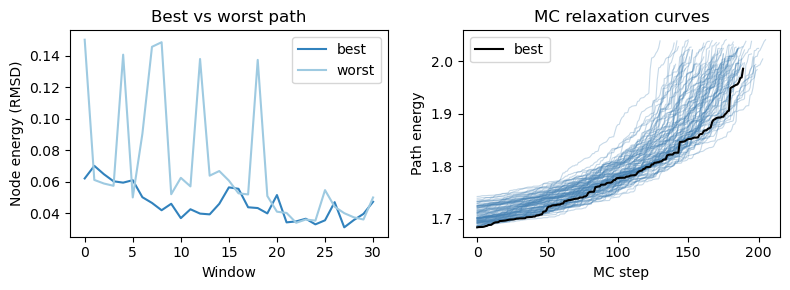

Rank 1 (energy=1.684) → /biggin/b212/bioc1781/Projects/CTNS/human/monomer/red-msa/with-dropout/raw_colabfold_outputs/run_01/mc_paths/path_rank_1.pdb
Rank 2 (energy=1.685) → /biggin/b212/bioc1781/Projects/CTNS/human/monomer/red-msa/with-dropout/raw_colabfold_outputs/run_01/mc_paths/path_rank_2.pdb
Rank 3 (energy=1.685) → /biggin/b212/bioc1781/Projects/CTNS/human/monomer/red-msa/with-dropout/raw_colabfold_outputs/run_01/mc_paths/path_rank_3.pdb
Rank 4 (energy=1.686) → /biggin/b212/bioc1781/Projects/CTNS/human/monomer/red-msa/with-dropout/raw_colabfold_outputs/run_01/mc_paths/path_rank_4.pdb
Rank 5 (energy=1.687) → /biggin/b212/bioc1781/Projects/CTNS/human/monomer/red-msa/with-dropout/raw_colabfold_outputs/run_01/mc_paths/path_rank_5.pdb


In [ ]:
_banner("8. Path Optimisation — Monte Carlo")

_mc_checkpoint = out_dir + 'mc_results.pkl'

if os.path.exists(_mc_checkpoint):
    with open(_mc_checkpoint, 'rb') as f:
        _mc_saved = pickle.load(f)
    _mc_structs = {s for row in _mc_saved.itertuples() for s in row.path}
    _ens_structs = set(ens.df.index)
    if _mc_structs.issubset(_ens_structs) and len(_mc_saved.iloc[0]["path"]) == mc_n_bins:
        finder.runs_df = _mc_saved
        print(f"  Loaded from checkpoint : {_mc_checkpoint}")
    else:
        n_missing = len(_mc_structs - _ens_structs)
        print(f"  Note: MC checkpoint has {n_missing} unknown structures or wrong bin count — will rerun")
else:
    print(f'  wf_step={mc_wf_step}  wf_cv={mc_wf_cv}  wf_odf={mc_wf_odf if mc_wf_odf is not None else 0.0:.3f}')
    _wf_odf = mc_wf_odf if mc_wf_odf is not None else 0.0
    finder.run(
        n_runs=mc_n_runs,
        num_processes=num_processes,
        reproducible_seeds=reproducible_seeds,
        fixed_endpoints=fixed_endstates,
        wf_step=mc_wf_step,
        wf_cv=mc_wf_cv,
        wf_odf=_wf_odf,
    )
    with open(_mc_checkpoint, 'wb') as f:
        pickle.dump(finder.runs_df, f)
    print(f"  Saved checkpoint → {_mc_checkpoint}")

print(f"\n  Best path energy  : {finder.runs_df.iloc[ 0]['energy']:.4f}")
print(f"  Worst path energy : {finder.runs_df.iloc[-1]['energy']:.4f}")

def plot_energy_per_window(runs_df, index, label, ax):
    path = runs_df.iloc[index]['path']
    energies = [
        np.sqrt(_step_matrix[
            np.where(ens.df.index.values == path[i])[0][0],
            np.where(ens.df.index.values == path[i+1])[0][0],
        ]**2)
        for i in range(mc_n_bins - 1)
    ]
    ax.plot(energies, label=label)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))

plot_energy_per_window(finder.runs_df, 0,  'best',  ax1)
plot_energy_per_window(finder.runs_df, -1, 'worst', ax1)
ax1.set_xlabel('Window'); ax1.set_ylabel('Node energy (RMSD)'); ax1.legend()
ax1.set_title('Best vs worst path')

for i in range(1, mc_n_runs):
    ax2.plot(finder.runs_df.iloc[i]['relaxation_energies'], alpha=0.3, color='steelblue', lw=0.8)
ax2.plot(finder.runs_df.iloc[0]['relaxation_energies'], color='black', lw=1.5, label='best')
ax2.set_xlabel('MC step'); ax2.set_ylabel('Path energy')
ax2.set_title('MC relaxation curves'); ax2.legend()

plt.tight_layout()
plt.show()

finder.write_paths(out_dir + 'mc_paths/', n=mc_n_paths_to_save, resid_offset=resid_offset)

## 9. Path Assessment

Visualises the best MC path in PC space and compares actual CV values at each window against the ideal linearly-spaced values. Large offsets suggest the MC struggled in that region — consider increasing `mc_n_bins` or `mc_n_runs`.


────────────────────────────────────────────────────────────────
  9. Path Assessment
────────────────────────────────────────────────────────────────
  Mean absolute offset from ideal : 1.7530
  Max  absolute offset from ideal : 4.0099  (window 16)


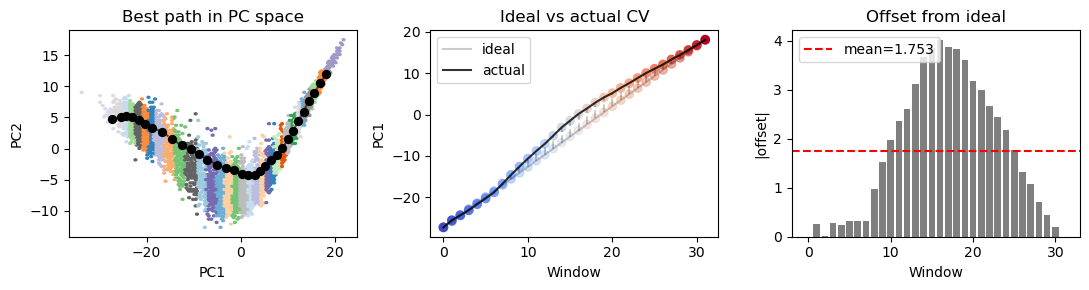

In [ ]:
_banner("9. Path Assessment")

actual_window_values, ideal_window_values = finder.get_window_values()
offsets = np.abs(ideal_window_values - actual_window_values)

print(f"  Mean absolute offset from ideal : {offsets.mean():.4f}")
print(f"  Max  absolute offset from ideal : {offsets.max():.4f}  (window {offsets.argmax()})")

fig, axs = plt.subplots(1, 3, figsize=(11, 3))

# panel 1: best path in PC space
hb = axs[0].hexbin(ens.df[plot_variable_1], ens.df[plot_variable_2],
                   C=ens.df['bin'], cmap='tab20c', reduce_C_function=np.amax)
best_path = finder.runs_df.iloc[0]['path']
for struct in best_path:
    axs[0].scatter(ens.df.loc[struct, plot_variable_1], ens.df.loc[struct, plot_variable_2],
                   c='black', s=32)
for i in range(len(best_path) - 1):
    x1, y1 = ens.df.loc[best_path[i],   plot_variable_1], ens.df.loc[best_path[i],   plot_variable_2]
    x2, y2 = ens.df.loc[best_path[i+1], plot_variable_1], ens.df.loc[best_path[i+1], plot_variable_2]
    axs[0].plot([x1, x2], [y1, y2], c='black', alpha=0.6, linestyle='dashed')
axs[0].set_xlabel(plot_variable_1); axs[0].set_ylabel(plot_variable_2)
axs[0].set_title('Best path in PC space')

# panel 2: ideal vs actual CV per window
axs[1].plot(ideal_window_values,  label='ideal',  color='black', alpha=0.2)
axs[1].scatter(range(mc_n_bins), ideal_window_values, c=range(mc_n_bins), cmap='coolwarm', alpha=0.5)
axs[1].plot(actual_window_values, label='actual', color='black', alpha=0.8)
axs[1].scatter(range(mc_n_bins), actual_window_values, c=range(mc_n_bins), cmap='coolwarm')
for i in range(mc_n_bins):
    axs[1].plot([i, i], [ideal_window_values[i], actual_window_values[i]],
                c='black', alpha=0.2, linestyle='dashed')
axs[1].set_xlabel('Window'); axs[1].set_ylabel(collective_variable)
axs[1].legend(); axs[1].set_title('Ideal vs actual CV')

# panel 3: per-window offset
axs[2].bar(range(mc_n_bins), offsets, color='black', alpha=0.5)
axs[2].axhline(offsets.mean(), color='red', linestyle='dashed', label=f'mean={offsets.mean():.3f}')
axs[2].set_xlabel('Window'); axs[2].set_ylabel('|offset|')
axs[2].set_title('Offset from ideal'); axs[2].legend()

plt.tight_layout()
plt.show()

## 10. Umbrella Sampling Setup

Embeds each window structure into the simulation template (protein + lipids + water) by replacing the protein coordinates, then writes PLUMED input files for both multi-directory and single-window runs.

**Note:** Always inspect output windows for clashes, particularly threaded lipids. The template should come from a prior simulation with a working topology.

In [ ]:
_banner("10. Umbrella Sampling Setup")

prep = UmbrellaSamplingPrep(
    path_finder=finder,
    ensemble=ens,
    template_pdb=template_pdb_for_umbrella_sampling,
    output_dir=out_dir + 'umbrella_sampling/',
)

prep.prepare_windows(resid_offset=resid_offset)
print(f"\n  Windows written → {out_dir}umbrella_sampling/")

prep.write_plumed_input(
    distances_dict=distances_to_evaluate if calculate_distances else None,
    resid_offset=resid_offset,
)
print(f"  PLUMED input written")


────────────────────────────────────────────────────────────────
  10. Umbrella Sampling Setup
────────────────────────────────────────────────────────────────


Preparing windows: 100%|██████████| 32/32 [09:09<00:00, 17.18s/it]



  Windows written → /biggin/b212/bioc1781/Projects/CTNS/human/monomer/red-msa/with-dropout/raw_colabfold_outputs/run_01/umbrella_sampling/
Number of atoms in the template universe:  217
Number of atoms in the ensemble universe:  217
  PLUMED input written


## 11. Debugging (Optional)

Compares CV values reported by PLUMED (from `COLVAR` files written during a short test run) against the MDA-computed projections. Run after an initial short simulation to verify PLUMED tracks the expected CV before committing to a full production run.

In [ ]:
_banner("11. Debugging — PLUMED CV verification")

import MDAnalysis as mda

umbrella_sampling_directory = out_dir + 'umbrella_sampling/'
colvar_files = glob.glob(umbrella_sampling_directory + 'window_*/COLVAR')
colvar_files.sort(key=lambda x: int(x.split('/')[-2].split('_')[1]))

actual_window_values, cv_values_for_plumed_input = finder.get_window_values()

n_sel = len(mda.Universe(out_dir + 'ensemble.pdb').select_atoms(ens.rmsd_selection))
print(f"  Atoms in rmsd_selection : {n_sel}")
print(f"  COLVAR files found      : {len(colvar_files)}")

if not colvar_files:
    print("\n  No COLVAR files found — run a short test simulation first.")
else:
    cv_values = []
    for file in colvar_files:
        with open(file) as f:
            lines = f.readlines()
            cv_values.append(float(lines[1].split()[1]))

    _max_dev = max(abs(cv_values[i] - actual_window_values[i]) for i in range(len(cv_values)))
    print(f"  Max |PLUMED − MDA| deviation : {_max_dev:.4f}")

    plt.figure(figsize=(6, 3))
    plt.plot(actual_window_values,       label='MDA actual', alpha=0.7, color='red')
    plt.plot(cv_values_for_plumed_input, label='ideal',      alpha=0.5, color='black', linestyle='dashed')
    plt.plot(cv_values,                  label='PLUMED',     alpha=0.7, color='steelblue')
    plt.xlabel('Window'); plt.ylabel(collective_variable)
    plt.title('CV cross-check: MDA vs PLUMED'); plt.legend()
    plt.tight_layout()
    plt.show()


────────────────────────────────────────────────────────────────
  11. Debugging — PLUMED CV verification
────────────────────────────────────────────────────────────────
  Atoms in rmsd_selection : 217
  COLVAR files found      : 0

  No COLVAR files found — run a short test simulation first.


## 12. Ramachandran Distance Matrix (Test)

Computes a pairwise circular distance matrix in φ/ψ space for the best MC path structures. Uses `d = sqrt(mean(2*(1-cos(Δθ))))` over all residue φ/ψ pairs — the circular analogue of RMSD, ranging from 0 (identical) to 2 (maximally different).


────────────────────────────────────────────────────────────────
  12. Ramachandran Distance Matrix (Test)
────────────────────────────────────────────────────────────────


Rama matrix: 100%|██████████| 1/1 [00:00<00:00, 173.88it/s]


  Rama matrix shape : (32, 32)
  min=0.0000  mean=0.0652  max=0.1036



RMSD matrix: 100%|██████████| 32/32 [00:00<00:00, 353.29it/s]


  RMSD matrix shape : (32, 32)
  min=0.0000  mean=1.2475  max=3.1478


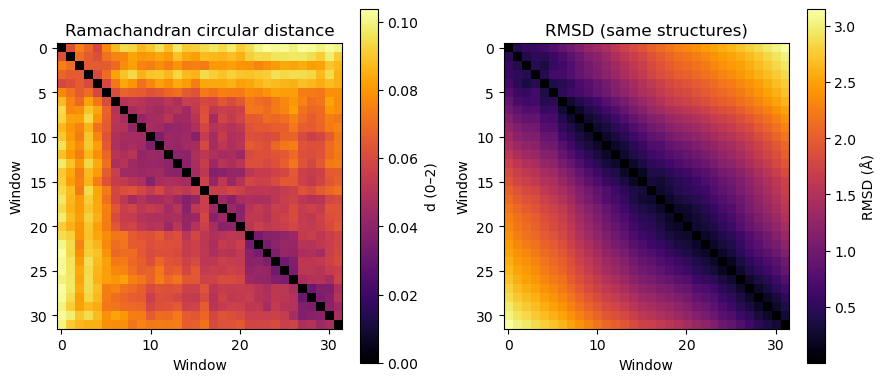

In [ ]:
_banner("12. Ramachandran Distance Matrix (Test)")

import importlib
from ensemblr import calc_matrices
importlib.reload(calc_matrices)

import MDAnalysis as mda

# Use the best MC path (32 structures) for a fast test — avoids loading all 3527 structures.
best_path = finder.runs_df.iloc[0]['path']
path_df   = ens.df.loc[best_path].copy()

rama_matrix = calc_matrices.get_ramachandran_matrix(path_df, structure_directory)

print(f"\n  Rama matrix shape : {rama_matrix.shape}")
print(f"  min={rama_matrix.min():.4f}  mean={rama_matrix[rama_matrix > 0].mean():.4f}  max={rama_matrix.max():.4f}")

# Compute RMSD matrix for the same path structures on the fly
if ens.rmsd_matrix is not None:
    path_idx = [np.where(ens.df.index == s)[0][0] for s in best_path]
    rmsd_sub = ens.rmsd_matrix[np.ix_(path_idx, path_idx)]
else:
    path_coords = np.array([
        mda.Universe(structure_directory + s).select_atoms(ens.rmsd_selection).positions
        for s in best_path
    ])
    rmsd_sub = calc_matrices.get_rmsdmat_jax(path_coords, path_df)

print(f"  RMSD matrix shape : {rmsd_sub.shape}")
print(f"  min={rmsd_sub.min():.4f}  mean={rmsd_sub[rmsd_sub > 0].mean():.4f}  max={rmsd_sub.max():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

im0 = axes[0].imshow(rama_matrix, cmap='inferno')
axes[0].set_title('Ramachandran circular distance')
axes[0].set_xlabel('Window'); axes[0].set_ylabel('Window')
fig.colorbar(im0, ax=axes[0], label='d (0–2)')

im1 = axes[1].imshow(rmsd_sub, cmap='inferno')
axes[1].set_title('RMSD (same structures)')
axes[1].set_xlabel('Window'); axes[1].set_ylabel('Window')
fig.colorbar(im1, ax=axes[1], label='RMSD (Å)')

plt.tight_layout()
plt.show()